Імпорти

In [2]:
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    MODEL_RESULTS_PATH,
    MODELS_DIR,
    TEST_PATH,
    TEXT_COLUMN,
    TARGET_COLUMN,
)

from src.evaluation import (
    calculate_classification_metrics,
    save_experiment_result,
)

1. Завантажуємо загальну таблицю

In [3]:
results_df = pd.read_csv(MODEL_RESULTS_PATH)

results_df

,model,parameters,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,train_time_sec,variant,split,n_features
0,DistilBERT,"{""checkpoint"": ""distilbert-base-uncased"", ""epo...",0.9065,0.900707,0.905698,0.913445,0.898439,420.774839,fine-tuned,validation,NaN
1,TF-IDF + Linear SVM,"{""classifier__C"": 1.0, ""tfidf__min_df"": 1, ""tf...",0.8790,0.873237,0.878779,0.881031,0.871352,3.870460,tuned,validation,2158.0
2,TF-IDF + Linear SVM,"{""C"": 1.0, ""min_df"": 2, ""ngram_range"": [1, 2],...",0.8755,0.870909,0.875092,0.879338,0.868093,0.367386,baseline,validation,8913.0
3,TF-IDF + Logistic Regression,"{""classifier__C"": 2.0, ""tfidf__min_df"": 2, ""tf...",0.8675,0.862007,0.867527,0.874387,0.858843,15.551374,tuned,validation,1331.0
4,TF-IDF + Logistic Regression,"{""C"": 1.0, ""min_df"": 2, ""ngram_range"": [1, 2],...",0.8410,0.829135,0.839451,0.854706,0.824639,2.555273,baseline,validation,8913.0
5,DummyClassifier,"{""strategy"": ""most_frequent""}",0.0190,0.000484,0.000709,0.000247,0.012987,0.001041,baseline,validation,NaN


In [4]:
results_df[
    [
        "model",
        "variant",
        "split",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "train_time_sec",
    ]
].sort_values(
    ["split", "macro_f1"],
    ascending=[True, False],
)

,model,variant,split,accuracy,macro_f1,weighted_f1,train_time_sec
0,DistilBERT,fine-tuned,validation,0.9065,0.900707,0.905698,420.774839
1,TF-IDF + Linear SVM,tuned,validation,0.8790,0.873237,0.878779,3.870460
2,TF-IDF + Linear SVM,baseline,validation,0.8755,0.870909,0.875092,0.367386
3,TF-IDF + Logistic Regression,tuned,validation,0.8675,0.862007,0.867527,15.551374
4,TF-IDF + Logistic Regression,baseline,validation,0.8410,0.829135,0.839451,2.555273
5,DummyClassifier,baseline,validation,0.0190,0.000484,0.000709,0.001041


Якщо є дублікати

In [ ]:
results_df = results_df.drop_duplicates(
    subset=["model", "variant", "split"],
    keep="last",
)

2. Порівнюємо validation-результати

In [5]:
validation_results = (
    results_df[results_df["split"] == "validation"]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

validation_results[
    [
        "model",
        "variant",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "macro_precision",
        "macro_recall",
        "train_time_sec",
    ]
]

,model,variant,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,train_time_sec
0,DistilBERT,fine-tuned,0.9065,0.900707,0.905698,0.913445,0.898439,420.774839
1,TF-IDF + Linear SVM,tuned,0.8790,0.873237,0.878779,0.881031,0.871352,3.870460
2,TF-IDF + Linear SVM,baseline,0.8755,0.870909,0.875092,0.879338,0.868093,0.367386
3,TF-IDF + Logistic Regression,tuned,0.8675,0.862007,0.867527,0.874387,0.858843,15.551374
4,TF-IDF + Logistic Regression,baseline,0.8410,0.829135,0.839451,0.854706,0.824639,2.555273
5,DummyClassifier,baseline,0.0190,0.000484,0.000709,0.000247,0.012987,0.001041


3. Графік Macro F1

In [6]:
validation_results["experiment"] = (
    validation_results["model"]
    + " — "
    + validation_results["variant"]
)

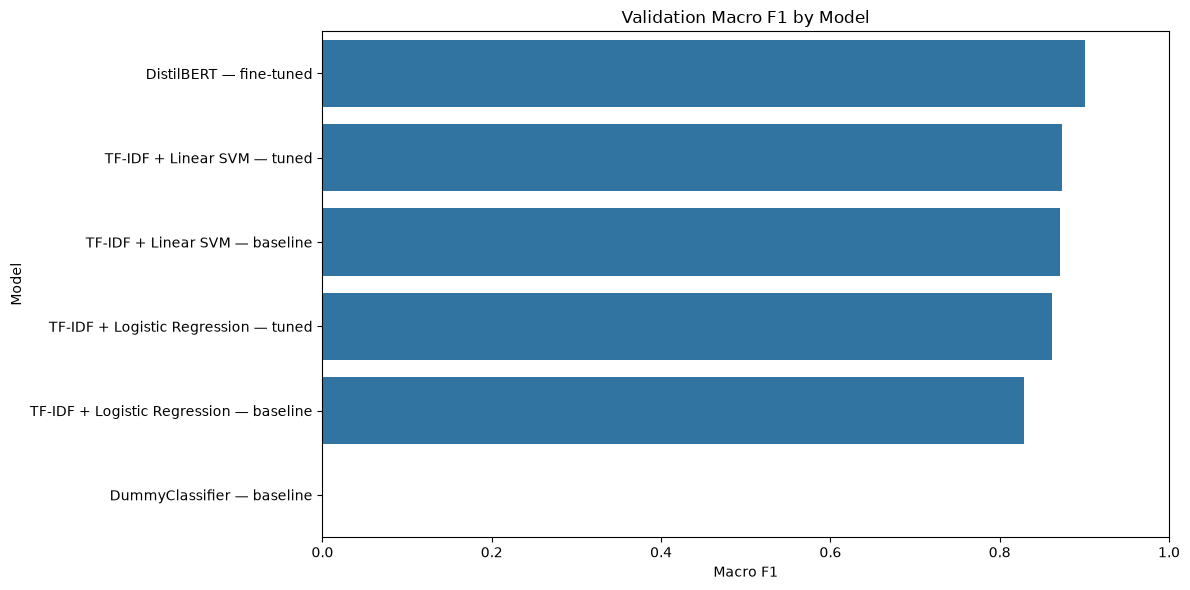

In [7]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=validation_results,
    x="macro_f1",
    y="experiment",
)

plt.title("Validation Macro F1 by Model")
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

DistilBERT демонструє найкращу якість, але потребує значно більше ресурсів і часу, тоді як Linear SVM забезпечує сильну якість за мінімальної обчислювальної вартості.

4. Порівняння часу навчання

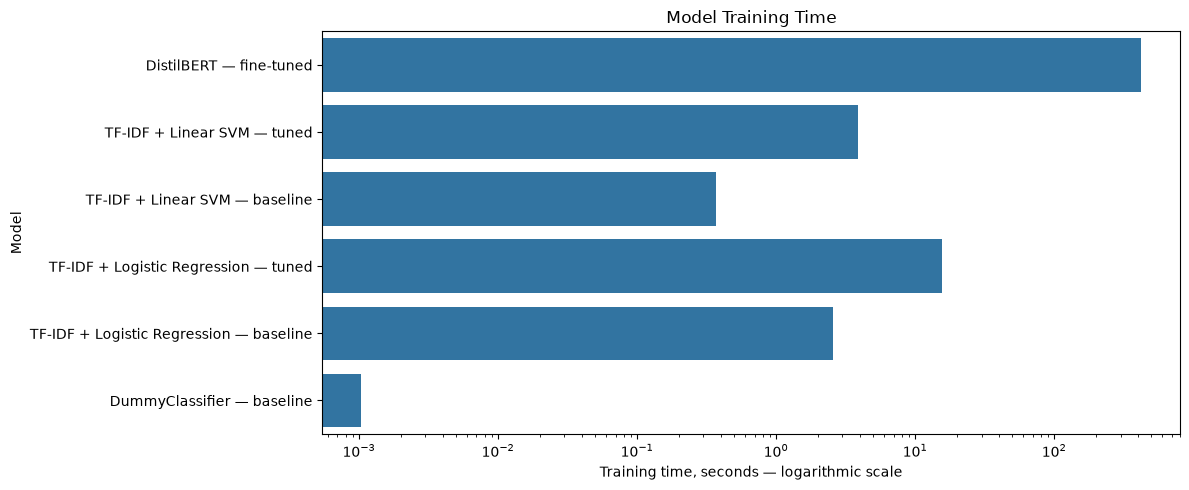

In [8]:
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=validation_results,
    x="train_time_sec",
    y="experiment",
)

ax.set_xscale("log")

plt.title("Model Training Time")
plt.xlabel("Training time, seconds — logarithmic scale")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

5. Автоматично обираємо моделі для фінального порівняння

In [9]:
final_validation_models = (
    validation_results
    .sort_values("macro_f1", ascending=False)
    .groupby("model", as_index=False)
    .first()
)

final_validation_models[
    ["model", "variant", "macro_f1"]
]

,model,variant,macro_f1
0,DistilBERT,fine-tuned,0.900707
1,DummyClassifier,baseline,0.000484
2,TF-IDF + Linear SVM,tuned,0.873237
3,TF-IDF + Logistic Regression,tuned,0.862007


6. Оцінюємо на тестовомоу датасеті

In [10]:
test_df = pd.read_csv(TEST_PATH)

X_test = test_df[TEXT_COLUMN]
y_test = test_df[TARGET_COLUMN]

print("Test size:", len(test_df))

Test size: 3080


In [11]:
BERT_TEXT_COLUMN = "text"

6.1 Оцінюємо Logistic Regression на test

In [15]:
logistic_model_path = (
    MODELS_DIR / "logistic_pipeline_tuned.joblib"
)

logistic_model = joblib.load(logistic_model_path)

start_time = time.perf_counter()
logistic_test_pred = logistic_model.predict(X_test)
logistic_inference_time = time.perf_counter() - start_time

In [17]:
parameters={
    "ngram_range": logistic_model.named_steps["tfidf"].ngram_range,
    "min_df": logistic_model.named_steps["tfidf"].min_df,
    "sublinear_tf": logistic_model.named_steps["tfidf"].sublinear_tf,
    "C": logistic_model.named_steps["classifier"].C,
}

logistic_test_result = calculate_classification_metrics(
    model_name="TF-IDF + Logistic Regression",
    y_true=y_test,
    y_pred=logistic_test_pred,
    parameters=parameters,
)

logistic_test_result.update({
    "variant": "tuned",
    "split": "test",
    "inference_time_sec": logistic_inference_time,
    "n_features": len(
        logistic_model
        .named_steps["tfidf"]
        .get_feature_names_out()
    ),
})

save_experiment_result(
    logistic_test_result,
    MODEL_RESULTS_PATH,
)

,model,parameters,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,train_time_sec,variant,split,n_features,inference_time_sec
0,DistilBERT,"{""checkpoint"": ""distilbert-base-uncased"", ""epo...",0.906500,0.900707,0.905698,0.913445,0.898439,420.774839,fine-tuned,validation,NaN,NaN
1,TF-IDF + Logistic Regression,"{""C"": 2.0, ""min_df"": 2, ""ngram_range"": [1, 1],...",0.881818,0.881908,0.881908,0.887893,0.881818,None,tuned,test,1331.0,0.018433
2,TF-IDF + Linear SVM,"{""classifier__C"": 1.0, ""tfidf__min_df"": 1, ""tf...",0.879000,0.873237,0.878779,0.881031,0.871352,3.87046,tuned,validation,2158.0,NaN
3,TF-IDF + Linear SVM,"{""C"": 1.0, ""min_df"": 2, ""ngram_range"": [1, 2],...",0.875500,0.870909,0.875092,0.879338,0.868093,0.367386,baseline,validation,8913.0,NaN
4,TF-IDF + Logistic Regression,"{""classifier__C"": 2.0, ""tfidf__min_df"": 2, ""tf...",0.867500,0.862007,0.867527,0.874387,0.858843,15.551374,tuned,validation,1331.0,NaN
5,TF-IDF + Logistic Regression,"{""C"": 1.0, ""min_df"": 2, ""ngram_range"": [1, 2],...",0.841000,0.829135,0.839451,0.854706,0.824639,2.555273,baseline,validation,8913.0,NaN
6,DummyClassifier,"{""strategy"": ""most_frequent""}",0.019000,0.000484,0.000709,0.000247,0.012987,0.001041,baseline,validation,NaN,NaN
